# <center> Capstone Project — The Battle of Neighborhoods

<center><em>IBM Data Science Professional Certificate | Coursera</em></center>
<center><em>Analysis of Fitness & Sport Facilities Distribution across Frankfurt am Main</em></center>

## Table of Contents
1. [Introduction to Business Problem](#1-introduction)
2. [Data Description](#2-data-description)
3. [Methodology](#3-methodology)
   - [3.1 Environment Setup](#31-environment-setup)
   - [3.2 Data Collection & Cleaning](#32-data-collection--cleaning)
   - [3.3 Geocoding](#33-geocoding)
   - [3.4 Borough Visualization](#34-borough-visualization)
   - [3.5 Google Places API — Venue Data](#35-google-places-api--venue-data)
   - [3.6 Exploratory Analysis & Venue Mapping](#36-exploratory-analysis--venue-mapping)
   - [3.7 Feature Engineering — One-Hot Encoding](#37-feature-engineering--one-hot-encoding)
   - [3.8 KMeans Clustering](#38-kmeans-clustering)
   - [3.9 Cluster Map Visualization](#39-cluster-map-visualization)
   - [3.10 Cluster Inspection](#310-cluster-inspection)
4. [Results and Discussion](#4-results-and-discussion)
5. [Conclusion](#5-conclusion)
6. [References](#6-references)

---
## 1. Introduction

Frankfurt am Main is Germany's financial capital and a global hub for commerce, culture, education, tourism, and transportation — the 5th largest city in the country. This diversity drives a wide variety of restaurants, bars, nightlife venues, shops, museums, and more. However, this project focuses on a specific aspect of daily life for residents: **access to sport and fitness facilities**.

### Business Problem
A business investor wants to open a new Fitness Center or Gym in Frankfurt. To make an informed decision, they need to understand:
- The **geographical distribution** of existing sport facilities across boroughs.
- Which areas are **oversaturated** with sport venues vs. which are underserved.
- Which **borough clusters** share similar fitness venue profiles.

This analysis provides data-driven recommendations on the best location(s) to open a new fitness business.

---
## 2. Data Description

The following datasets are used in this project:

| Source | Description | Usage |
|--------|-------------|-------|
| [Wikipedia — Frankfurt Ortsbezirke](https://de.wikipedia.org/wiki/Liste_der_Ortsbezirke_von_Frankfurt_am_Main) | List of Frankfurt boroughs with neighborhood names | Borough names and structure |
| [Nominatim / OpenStreetMap](https://nominatim.org/) | Free geocoding API | Latitude/Longitude for each borough |
| [Google Places API](https://developers.google.com/maps/documentation/places/web-service) | Venue data by location and category | Fitness/sport facility listings with ratings & reviews |
| [Frankfurt GeoJSON](https://offenedaten.frankfurt.de/) | Official Frankfurt district boundary polygons | Choropleth map overlays |

**Target venue type:** `gym` (Google Places type — covers gyms, fitness centers, sport clubs)

**Why Google Places over Foursquare?**
- More comprehensive and up-to-date venue coverage in Germany
- Rich metadata: star ratings, review counts, price level, opening hours
- Pagination support — up to 60 results per borough (3 pages × 20 results)
- $200/month free credit covers ~5,000 Nearby Search requests

---
## 3. Methodology

The workflow follows these steps:
1. **Scrape** borough data from Wikipedia.
2. **Geocode** each borough using Nominatim.
3. **Query** Google Places API for sport/fitness venues per borough.
4. **Engineer features** via one-hot encoding of venue categories.
5. **Cluster** boroughs using KMeans.
6. **Visualize** results on interactive Folium maps.

### 3.1 Environment Setup

Install required packages. All packages are compatible with **Python 3.12**.

In [12]:
"""
# Install dependencies — run once
%pip install -q pandas requests beautifulsoup4 lxml
%pip install -q geopy folium
%pip install -q scikit-learn matplotlib
print("All packages installed successfully.")
"""

'\n# Install dependencies — run once\n%pip install -q pandas requests beautifulsoup4 lxml\n%pip install -q geopy folium\n%pip install -q scikit-learn matplotlib\nprint("All packages installed successfully.")\n'

In [13]:
# Core library imports
import sys
import time
import warnings

import pandas as pd
import numpy as np
import requests

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import folium
from folium.plugins import MarkerCluster

warnings.filterwarnings('ignore')

print(f"Python version : {sys.version}")
print(f"pandas         : {pd.__version__}")
print(f"numpy          : {np.__version__}")
print(f"scikit-learn   : {__import__('sklearn').__version__}")
print(f"folium         : {folium.__version__}")
print("Imports successful.")

Python version : 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
pandas         : 2.3.3
numpy          : 2.3.4
scikit-learn   : 1.7.2
folium         : 0.20.0
Imports successful.


---
### 3.2 Data Collection & Cleaning

We scrape the list of Frankfurt boroughs (*Ortsbezirke*) from the German Wikipedia page.

In [14]:
# Scrape borough data from Wikipedia
WIKI_URL = "https://de.wikipedia.org/wiki/Liste_der_Ortsbezirke_von_Frankfurt_am_Main"

# Fetch HTML manually with a browser-like User-Agent to avoid Wikipedia blocking
headers = {"User-Agent": "Mozilla/5.0 (compatible; FrankfurtAnalyzer/1.0)"}
response = requests.get(WIKI_URL, headers=headers, timeout=15)
response.raise_for_status()

# Pass the raw HTML string to read_html — NOT the URL
# This avoids pandas making its own unheadered request (which gets blocked)
dataframe_list = pd.read_html(response.text)
print(f"Number of tables found on the Wikipedia page: {len(dataframe_list)}")

Number of tables found on the Wikipedia page: 1


In [15]:
# Select the first (main) table and inspect it
frankfurt_data = dataframe_list[0].copy()
print("Raw columns:", frankfurt_data.columns.tolist())
frankfurt_data.head()

Raw columns: ['Nr.', 'Name', 'Stadtteile', 'Einwohnerzahl[1]', 'Fläche (km²)[2]', 'Bevölkerungsdichte (Einwohner/km²)', 'Ortsvorsteher[3]']


,Nr.,Name,Stadtteile,Einwohnerzahl[1],Fläche (km²)[2],Bevölkerungsdichte (Einwohner/km²),Ortsvorsteher[3]
0,1,Innenstadt I,"Gallus, Gutleutviertel, Bahnhofsviertel, Altst...",63.171,8848,7.140,Michael Weber (CDU)
1,2,Innenstadt II,"Bockenheim, Westend-Süd, Westend-Nord",71.684,12160,5.895,Axel Kaufmann (CDU) (ww)
2,3,Innenstadt III,"Nordend-West, Nordend-Ost",54.046,4632,11.668,Karin Guder (Grüne) (ww)
3,4,Bornheim/Ostend,"Ostend, Bornheim",60.410,8350,7.235,Herrmann Steib (Grüne)
4,5,Süd,"Flughafen, Sachsenhausen-Süd, Sachsenhausen-No...",102.330,67778,1.510,Christian Becker (CDU) (nw)


In [16]:
# Keep only borough name and neighbourhoods columns
cols_to_keep = [col for col in frankfurt_data.columns
                if any(k in str(col) for k in ['Name', 'Stadtteile'])]

frankfurt_data = frankfurt_data[cols_to_keep].copy()

# Rename columns to English — avoid shadowing built-in 'dict'
rename_map = {col: ('Borough' if 'Name' in str(col) else 'Neighbourhood')
              for col in frankfurt_data.columns}
frankfurt_data.rename(columns=rename_map, inplace=True)

# Drop rows with missing borough names
frankfurt_data.dropna(subset=['Borough'], inplace=True)
frankfurt_data.reset_index(drop=True, inplace=True)

print(f"Total boroughs: {len(frankfurt_data)}")
frankfurt_data.head(10)

Total boroughs: 16


,Borough,Neighbourhood
0,Innenstadt I,"Gallus, Gutleutviertel, Bahnhofsviertel, Altst..."
1,Innenstadt II,"Bockenheim, Westend-Süd, Westend-Nord"
2,Innenstadt III,"Nordend-West, Nordend-Ost"
3,Bornheim/Ostend,"Ostend, Bornheim"
4,Süd,"Flughafen, Sachsenhausen-Süd, Sachsenhausen-No..."
5,West,"Schwanheim, Griesheim, Nied, Sossenheim, Höchs..."
6,Mitte-West,"Rödelheim, Praunheim, Hausen, STB 343"
7,Nord-West,"Niederursel, Heddernheim, STB 426 (Praunheim-N..."
8,Mitte-Nord,"Eschersheim, Ginnheim, Dornbusch"
9,Nord-Ost,"Eckenheim, Preungesheim, Berkersheim, Frankfur..."


---
### 3.3 Geocoding

We use **Nominatim** (OpenStreetMap) to obtain latitude and longitude for each Frankfurt borough.  
A `RateLimiter` is applied to respect Nominatim's usage policy (1 request/second).

In [17]:
# Initialize geocoder with rate limiter
geolocator = Nominatim(user_agent="frankfurt_neighborhood_explorer_v2", timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.1, error_wait_seconds=5.0)

def get_coordinates(borough: str, city: str = "Frankfurt am Main", country: str = "DE") -> tuple[float | None, float | None]:
    """Geocode a borough name. Returns (latitude, longitude) or (None, None) on failure."""
    query = f"{borough}, {city}, {country}"
    try:
        location = geocode(query)
        if location:
            return location.latitude, location.longitude
    except Exception as e:
        print(f"Geocoding failed for '{borough}': {e}")
    return None, None

# Geocode all boroughs
print("Geocoding boroughs (this may take ~1 minute)...")
lat_list, lon_list = [], []
for borough in frankfurt_data['Borough']:
    lat, lon = get_coordinates(borough)
    lat_list.append(lat)
    lon_list.append(lon)
    status = f"{lat:.4f}, {lon:.4f}" if lat else "NOT FOUND"
    print(f"  {borough:<30} → {status}")

frankfurt_data['Latitude']  = lat_list
frankfurt_data['Longitude'] = lon_list

# Drop rows that could not be geocoded
before = len(frankfurt_data)
frankfurt_data.dropna(subset=['Latitude', 'Longitude'], inplace=True)
frankfurt_data.reset_index(drop=True, inplace=True)
print(f"\n Geocoded {len(frankfurt_data)} / {before} boroughs successfully.")
frankfurt_data.head()

Geocoding boroughs (this may take ~1 minute)...
  Innenstadt I                   → 50.1146, 8.6836
  Innenstadt II                  → 50.1146, 8.6836
  Innenstadt III                 → NOT FOUND
  Bornheim/Ostend                → 50.1251, 8.7123
  Süd                            → 50.0619, 8.6376
  West                           → 50.0980, 8.5463
  Mitte-West                     → 50.1379, 8.6123
  Nord-West                      → 50.1670, 8.6191
  Mitte-Nord                     → 50.1548, 8.6619
  Nord-Ost                       → 50.1632, 8.6939
  Ost                            → 50.1357, 8.7480
  Kalbach/Riedberg               → 50.1863, 8.6392
  Nieder-Erlenbach               → 50.2026, 8.7120
  Harheim                        → 50.1823, 8.6930
  Nieder-Eschbach                → 50.2018, 8.6666
  Bergen-Enkheim                 → 50.1581, 8.7619

 Geocoded 15 / 16 boroughs successfully.


,Borough,Neighbourhood,Latitude,Longitude
0,Innenstadt I,"Gallus, Gutleutviertel, Bahnhofsviertel, Altst...",50.114558,8.683591
1,Innenstadt II,"Bockenheim, Westend-Süd, Westend-Nord",50.114558,8.683591
2,Bornheim/Ostend,"Ostend, Bornheim",50.125123,8.712301
3,Süd,"Flughafen, Sachsenhausen-Süd, Sachsenhausen-No...",50.061914,8.637550
4,West,"Schwanheim, Griesheim, Nied, Sossenheim, Höchs...",50.098031,8.546335


In [18]:
# Get city-level coordinates for map centering
city_location = geocode("Frankfurt am Main, DE")
CITY_LAT = city_location.latitude
CITY_LON = city_location.longitude
print(f"Frankfurt city center: {CITY_LAT:.5f}, {CITY_LON:.5f}")

Frankfurt city center: 50.11064, 8.68209


---
### 3.4 Borough Visualization

Visualize all boroughs on an interactive Folium map with GeoJSON district boundaries.

In [19]:
# ── GeoJSON Sources (in order of preference) ──────────────────────────────────
# The original offenedaten.frankfurt.de URL returns 404 — file has been moved.
# We try two reliable alternatives:

GEOJSON_SOURCES = [
    # 1. GitHub — codeforgermany (stable, community-maintained)
    "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/frankfurt-main.geojson",
    # 2. ArcGIS Hub — official Frankfurt Stadtteile (updated Feb 2025)
    "https://services.arcgis.com/OLiydejKCZTGhvWg/arcgis/rest/services/Stadtteile_Frankfurt_am_Main/FeatureServer/0/query?where=1%3D1&outFields=*&f=geojson",
]

FRANKFURT_GEOJSON = None

for url in GEOJSON_SOURCES:
    try:
        geo_resp = requests.get(url, timeout=15)
        geo_resp.raise_for_status()
        FRANKFURT_GEOJSON = geo_resp.json()
        print(f"✅ GeoJSON loaded successfully from:\n   {url}")
        break  # stop at first working source
    except requests.RequestException as e:
        print(f"⚠️  Source failed: {url}\n   Reason: {e}")

if FRANKFURT_GEOJSON is None:
    print("❌ All GeoJSON sources failed — maps will render without district boundaries.")

✅ GeoJSON loaded successfully from:
   https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/frankfurt-main.geojson


In [20]:
def create_borough_map(df: pd.DataFrame, center_lat: float, center_lon: float) -> folium.Map:
    """Create a Folium map with borough markers and GeoJSON district overlay."""
    fmap = folium.Map(location=[center_lat, center_lon], zoom_start=12,
                      tiles="CartoDB positron")

    # Add district boundaries using pre-fetched GeoJSON dict
    if FRANKFURT_GEOJSON:
        folium.GeoJson(
            FRANKFURT_GEOJSON,
            name="Borough Boundaries",
            style_function=lambda x: {
                "fillColor": "#3186cc",
                "color":     "#1a5276",
                "weight":    1.5,
                "fillOpacity": 0.08,
            }
        ).add_to(fmap)

    # Add borough markers
    for _, row in df.iterrows():
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=6,
            popup=folium.Popup(f"<b>{row['Borough']}</b>", max_width=200),
            tooltip=row['Borough'],
            color="#e8a317",
            fill=True,
            fill_color="#3186cc",
            fill_opacity=0.75,
        ).add_to(fmap)

    folium.LayerControl().add_to(fmap)
    return fmap

borough_map = create_borough_map(frankfurt_data, CITY_LAT, CITY_LON)
borough_map

---
### 3.5 Google Places API — Venue Data

We use the **Google Places Nearby Search API** to retrieve fitness and gym venues around each borough centroid.

> **Setup:**
> 1. Go to [https://console.cloud.google.com](https://console.cloud.google.com)
> 2. Create a project → Enable **Places API**
> 3. Create an API key under *Credentials*
> 4. Paste the key below

In [ ]:
# ── Google Places API credentials ─────────────────────────────────────────────
GOOGLE_API_KEY = "Here_your_API"  # Replace with your key
GOOGLE_URL     = "https://maps.googleapis.com/maps/api/place/nearbysearch/json"

# ── Constants ─────────────────────────────────────────────────────────────────
SEARCH_RADIUS_M = 3000   # metres around each borough centroid
PLACE_TYPE      = "gym"  # Google Places type — covers gyms & fitness centres

# ── Test API key before full scrape ───────────────────────────────────────────
print("Testing Google Places API key...")
test_params = {
    "location": "50.1109,8.6821",  # Frankfurt city centre
    "radius":   100,
    "type":     PLACE_TYPE,
    "key":      GOOGLE_API_KEY,
}
test_resp = requests.get(GOOGLE_URL, params=test_params, timeout=10)
test_json = test_resp.json()
status    = test_json.get("status")

if status in ("OK", "ZERO_RESULTS"):
    print("✅ API key valid — proceeding with full scrape.")
elif status == "REQUEST_DENIED":
    raise ValueError(
        "❌ REQUEST_DENIED — key invalid or Places API not enabled.\n"
        "   Enable it at: https://console.cloud.google.com"
    )
else:
    raise ValueError(f"❌ Unexpected status: {status}\n{test_json}")

Testing Google Places API key...
✅ API key valid — proceeding with full scrape.


In [22]:
# Generic place type tags to filter out from Google's type list
GENERIC_TYPES = {"point_of_interest", "establishment", "health", "store", "food"}

def fetch_places_page(params: dict) -> tuple[list[dict], str | None]:
    """
    Fetch one page of Google Places Nearby Search results.
    Returns (results_list, next_page_token or None).
    """
    resp = requests.get(GOOGLE_URL, params=params, timeout=15)
    resp.raise_for_status()
    data = resp.json()
    return data.get("results", []), data.get("next_page_token")


def get_nearby_venues_google(
    names:      list[str],
    latitudes:  list[float],
    longitudes: list[float],
    radius:     int = SEARCH_RADIUS_M,
    place_type: str = PLACE_TYPE,
    max_pages:  int = 3,   # 3 pages × 20 results = up to 60 per borough
) -> pd.DataFrame:
    """
    Query Google Places Nearby Search for fitness venues near each borough centroid.
    Supports pagination via next_page_token (up to 60 results per borough).
    Returns a flat DataFrame with venue details, ratings, and review counts.
    """
    venues_list: list[dict] = []

    for name, lat, lng in zip(names, latitudes, longitudes):
        borough_results: list[dict] = []
        params = {
            "location": f"{lat},{lng}",
            "radius":   radius,
            "type":     place_type,
            "key":      GOOGLE_API_KEY,
        }

        # Paginate through up to max_pages pages
        for page_num in range(max_pages):
            try:
                results, next_token = fetch_places_page(params)
                borough_results.extend(results)
            except requests.RequestException as e:
                print(f" Error for '{name}' page {page_num + 1}: {e}")
                break

            if not next_token:
                break

            # Google requires a short delay before the next_page_token becomes valid
            time.sleep(2)
            params = {"pagetoken": next_token, "key": GOOGLE_API_KEY}

        # Extract fields from each result
        for v in borough_results:
            loc   = v.get("geometry", {}).get("location", {})
            types = v.get("types", [])

            # Pick the most descriptive type — skip generic labels
            specific = [t for t in types if t not in GENERIC_TYPES]
            venue_cat = (specific[0] if specific else types[0] if types else "unknown")
            venue_cat = venue_cat.replace("_", " ").title()

            venues_list.append({
                "Borough":           name,
                "Borough Latitude":  lat,
                "Borough Longitude": lng,
                "Venue":             v.get("name", "Unknown"),
                "Venue Latitude":    loc.get("lat"),
                "Venue Longitude":   loc.get("lng"),
                "Venue Category":    venue_cat,
                "Rating":            v.get("rating"),             # ⭐ 1.0–5.0
                "User Ratings":      v.get("user_ratings_total"), # review count
                "Price Level":       v.get("price_level"),        # 0–4
                "Open Now":          v.get("opening_hours", {}).get("open_now"),
            })

        time.sleep(0.5)  # polite delay between boroughs
        print(f"  {name:<30} → {len(borough_results)} venues")

    return pd.DataFrame(venues_list)


# ── Run full scrape ────────────────────────────────────────────────────────────
print("Querying Google Places API for fitness venues per borough...\n")
frankfurt_venues = get_nearby_venues_google(
    names      = frankfurt_data['Borough'].tolist(),
    latitudes  = frankfurt_data['Latitude'].tolist(),
    longitudes = frankfurt_data['Longitude'].tolist(),
)

print(f"\n Total venues retrieved : {len(frankfurt_venues)}")
print(f"   DataFrame shape        : {frankfurt_venues.shape}")
frankfurt_venues.head()

Querying Google Places API for fitness venues per borough...

  Innenstadt I                   → 60 venues
  Innenstadt II                  → 60 venues
  Bornheim/Ostend                → 60 venues
  Süd                            → 11 venues
  West                           → 16 venues
  Mitte-West                     → 34 venues
  Nord-West                      → 23 venues
  Mitte-Nord                     → 39 venues
  Nord-Ost                       → 21 venues
  Ost                            → 43 venues
  Kalbach/Riedberg               → 19 venues
  Nieder-Erlenbach               → 16 venues
  Harheim                        → 21 venues
  Nieder-Eschbach                → 12 venues
  Bergen-Enkheim                 → 25 venues

 Total venues retrieved : 460
   DataFrame shape        : (460, 11)


,Borough,Borough Latitude,Borough Longitude,Venue,Venue Latitude,Venue Longitude,Venue Category,Rating,User Ratings,Price Level,Open Now
0,Innenstadt I,50.114558,8.683591,Inside Yoga Frankfurt,50.116299,8.684151,Gym,4.5,103.0,None,True
1,Innenstadt I,50.114558,8.683591,PRIME TIME fitness Westend,50.117507,8.666370,Gym,4.4,365.0,None,True
2,Innenstadt I,50.114558,8.683591,Happy Fitness,50.120353,8.697325,Gym,4.6,101.0,None,True
3,Innenstadt I,50.114558,8.683591,Fitness First Frankfurt - Eschenheimer Turm,50.116653,8.676866,Gym,4.8,1252.0,None,True
4,Innenstadt I,50.114558,8.683591,Fast forms,50.118369,8.680030,Gym,4.5,22.0,None,True


---
### 3.6 Exploratory Analysis & Venue Mapping

In [23]:
# Working DataFrame — drop rows with missing coordinates
frankfurt_venues_all = frankfurt_venues[
    ["Borough", "Venue", "Venue Latitude", "Venue Longitude",
     "Venue Category", "Rating", "User Ratings"]
].dropna(subset=["Venue Latitude", "Venue Longitude"]).reset_index(drop=True)

# Venue count per borough
venues_per_borough = frankfurt_venues_all.groupby("Borough").size().sort_values(ascending=False)
print("Venues per borough:")
print(venues_per_borough.to_string())

Venues per borough:
Borough
Bornheim/Ostend     60
Innenstadt II       60
Innenstadt I        60
Ost                 43
Mitte-Nord          39
Mitte-West          34
Bergen-Enkheim      25
Nord-West           23
Harheim             21
Nord-Ost            21
Kalbach/Riedberg    19
West                16
Nieder-Erlenbach    16
Nieder-Eschbach     12
Süd                 11


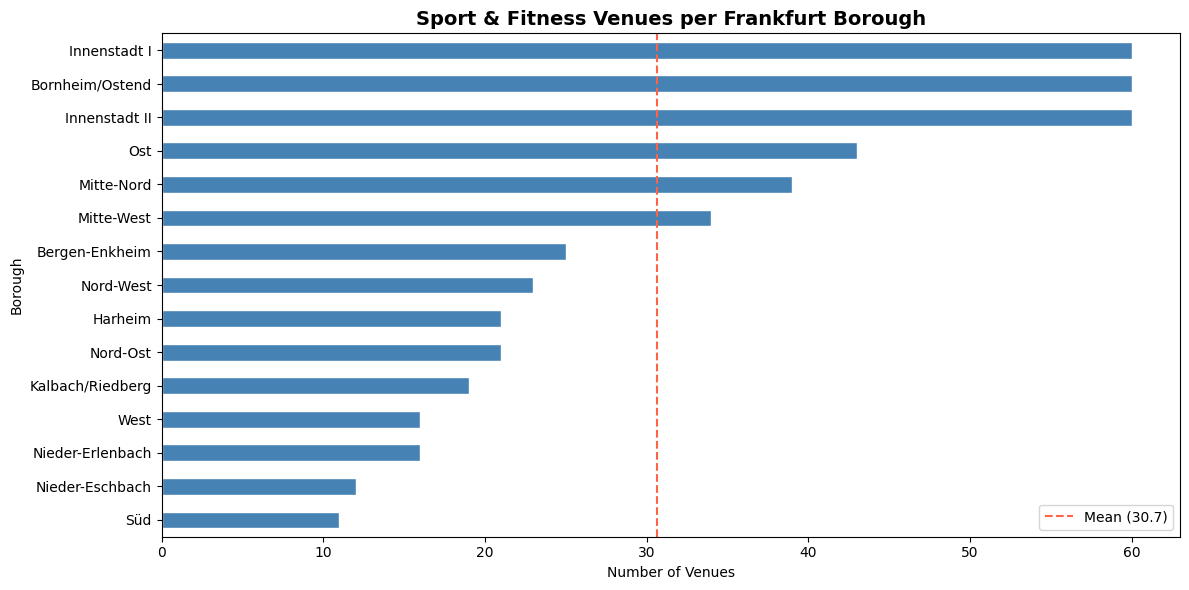

Chart saved.


In [24]:
# Bar chart — venues per borough
fig, ax = plt.subplots(figsize=(12, 6))
venues_per_borough.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Sport & Fitness Venues per Frankfurt Borough", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Venues")
ax.set_ylabel("Borough")
ax.axvline(venues_per_borough.mean(), color='tomato', linestyle='--',
           label=f'Mean ({venues_per_borough.mean():.1f})')
ax.legend()
plt.tight_layout()
plt.savefig("venues_per_borough.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

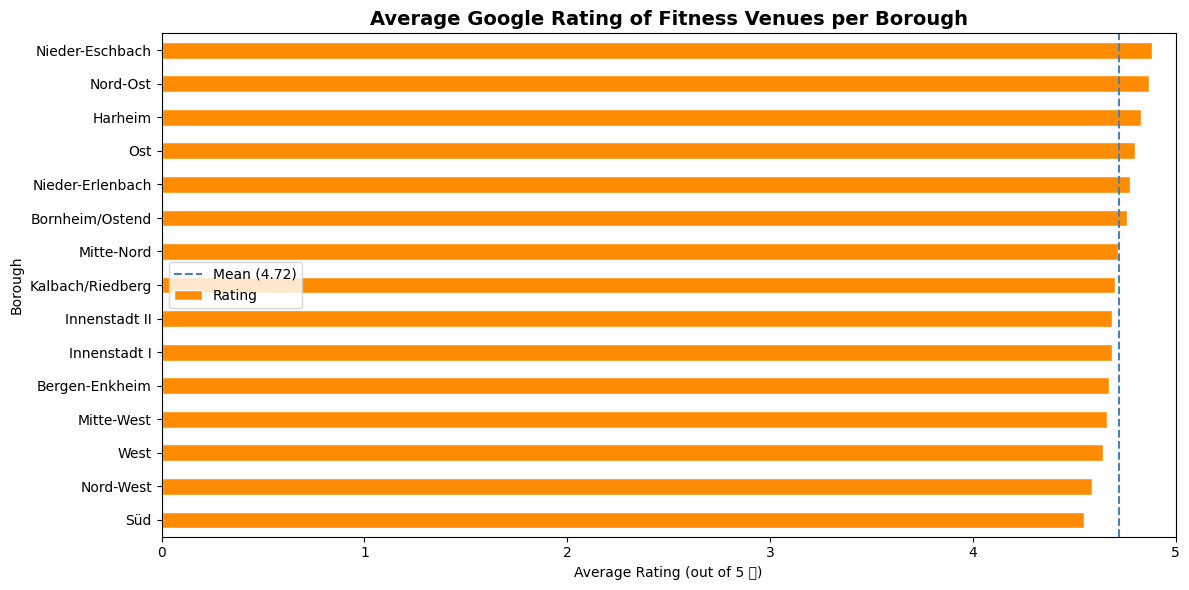

In [25]:
# Average Google rating per borough — bonus insight from Google Places data
avg_rating = (
    frankfurt_venues_all.groupby("Borough")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .dropna()
)

fig, ax = plt.subplots(figsize=(12, 6))
avg_rating.sort_values().plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.set_title("Average Google Rating of Fitness Venues per Borough", fontsize=14, fontweight='bold')
ax.set_xlabel("Average Rating (out of 5 ⭐)")
ax.set_ylabel("Borough")
ax.axvline(avg_rating.mean(), color='steelblue', linestyle='--',
           label=f'Mean ({avg_rating.mean():.2f})')
ax.set_xlim(0, 5)
ax.legend()
plt.tight_layout()
plt.savefig("avg_rating_per_borough.png", dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Top venue categories
unique_cats = frankfurt_venues_all["Venue Category"].value_counts()
print(f"Unique venue categories: {len(unique_cats)}")
print(unique_cats)

Unique venue categories: 8
Venue Category
Gym                436
Physiotherapist     10
Cafe                 5
Amusement Park       3
Spa                  2
Clothing Store       2
Shoe Store           1
Lodging              1
Name: count, dtype: int64


In [27]:
# Interactive map — venues colour-coded by category, rating shown in popup
venues_map = folium.Map(location=[CITY_LAT, CITY_LON], zoom_start=11, tiles="CartoDB positron")

if FRANKFURT_GEOJSON:
    folium.GeoJson(
        FRANKFURT_GEOJSON, name="Borough Boundaries",
        style_function=lambda x: {"fillColor": "none", "color": "#555", "weight": 1}
    ).add_to(venues_map)

# Colour-code markers by venue category
cat_list  = frankfurt_venues_all["Venue Category"].unique().tolist()
palette   = plt.get_cmap("tab20", len(cat_list))
cat_color = {cat: mcolors.rgb2hex(palette(i)) for i, cat in enumerate(cat_list)}

mc = MarkerCluster(name="Fitness Venues").add_to(venues_map)
for _, row in frankfurt_venues_all.iterrows():
    rating_str  = f"⭐ {row['Rating']}" if pd.notna(row.get('Rating')) else "No rating"
    reviews_str = f"({int(row['User Ratings'])} reviews)" if pd.notna(row.get('User Ratings')) else ""
    folium.CircleMarker(
        location=[row["Venue Latitude"], row["Venue Longitude"]],
        radius=5,
        popup=folium.Popup(
            f"<b>{row['Venue']}</b><br>"
            f"{row['Venue Category']}<br>"
            f"{rating_str} {reviews_str}<br>"
            f"<i>{row['Borough']}</i>",
            max_width=260,
        ),
        tooltip=row["Venue"],
        color="white",
        fill=True,
        fill_color=cat_color.get(row["Venue Category"], "green"),
        fill_opacity=0.85,
    ).add_to(mc)

folium.LayerControl().add_to(venues_map)
venues_map

---
### 3.7 Feature Engineering — One-Hot Encoding

We encode venue categories using one-hot encoding, then group by borough to get mean frequencies.

In [28]:
# One-hot encode venue categories
onehot = pd.get_dummies(frankfurt_venues_all[["Venue Category"]], prefix="", prefix_sep="")
onehot["Borough"] = frankfurt_venues_all["Borough"].values

# Move Borough to first column
cols   = ["Borough"] + [c for c in onehot.columns if c != "Borough"]
onehot = onehot[cols]

print(f"One-hot encoded shape: {onehot.shape}")
onehot.head()

One-hot encoded shape: (460, 9)


,Borough,Amusement Park,Cafe,Clothing Store,Gym,Lodging,Physiotherapist,Shoe Store,Spa
0,Innenstadt I,False,False,False,True,False,False,False,False
1,Innenstadt I,False,False,False,True,False,False,False,False
2,Innenstadt I,False,False,False,True,False,False,False,False
3,Innenstadt I,False,False,False,True,False,False,False,False
4,Innenstadt I,False,False,False,True,False,False,False,False


In [29]:
# Group by borough — mean frequency per category
frankfurt_grouped = onehot.groupby("Borough").mean(numeric_only=True).reset_index()
print(f"Grouped shape: {frankfurt_grouped.shape}")
frankfurt_grouped.head()

Grouped shape: (15, 9)


,Borough,Amusement Park,Cafe,Clothing Store,Gym,Lodging,Physiotherapist,Shoe Store,Spa
0,Bergen-Enkheim,0.0,0.000000,0.0,0.880000,0.0,0.040000,0.0,0.08
1,Bornheim/Ostend,0.0,0.016667,0.0,0.983333,0.0,0.000000,0.0,0.00
2,Harheim,0.0,0.047619,0.0,0.857143,0.0,0.095238,0.0,0.00
3,Innenstadt I,0.0,0.016667,0.0,0.966667,0.0,0.016667,0.0,0.00
4,Innenstadt II,0.0,0.016667,0.0,0.966667,0.0,0.016667,0.0,0.00


In [30]:
def get_top_venues(row: pd.Series, n: int = 10) -> list[str]:
    """Return the top-n venue category names sorted by frequency for a given borough row."""
    return row.iloc[1:].sort_values(ascending=False).index[:n].tolist()

NUM_TOP  = 10
suffixes = {1: "st", 2: "nd", 3: "rd"}
top_columns = [f"{i}{suffixes.get(i, 'th')} Most Common Venue" for i in range(1, NUM_TOP + 1)]

borough_venues_sorted = frankfurt_grouped[["Borough"]].copy()
for col, values in zip(
    top_columns,
    zip(*frankfurt_grouped.apply(lambda r: get_top_venues(r, NUM_TOP), axis=1))
):
    borough_venues_sorted[col] = values

print("Top venue categories per borough:")
borough_venues_sorted.head(10)

Top venue categories per borough:


,Borough,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue
0,Bergen-Enkheim,Gym,Spa,Physiotherapist,Amusement Park,Cafe,Clothing Store,Lodging,Shoe Store
1,Bornheim/Ostend,Gym,Cafe,Amusement Park,Clothing Store,Lodging,Physiotherapist,Shoe Store,Spa
2,Harheim,Gym,Physiotherapist,Cafe,Amusement Park,Clothing Store,Lodging,Shoe Store,Spa
3,Innenstadt I,Gym,Cafe,Physiotherapist,Amusement Park,Clothing Store,Lodging,Shoe Store,Spa
4,Innenstadt II,Gym,Cafe,Physiotherapist,Amusement Park,Clothing Store,Lodging,Shoe Store,Spa
5,Kalbach/Riedberg,Gym,Amusement Park,Cafe,Clothing Store,Lodging,Physiotherapist,Shoe Store,Spa
6,Mitte-Nord,Gym,Amusement Park,Cafe,Clothing Store,Lodging,Physiotherapist,Shoe Store,Spa
7,Mitte-West,Gym,Clothing Store,Amusement Park,Lodging,Physiotherapist,Cafe,Shoe Store,Spa
8,Nieder-Erlenbach,Gym,Physiotherapist,Cafe,Amusement Park,Clothing Store,Lodging,Shoe Store,Spa
9,Nieder-Eschbach,Gym,Amusement Park,Cafe,Clothing Store,Lodging,Physiotherapist,Shoe Store,Spa


---
### 3.8 KMeans Clustering

We cluster boroughs by their venue category profiles.  
The **Elbow Method** is used to select an appropriate number of clusters, then KMeans is applied.

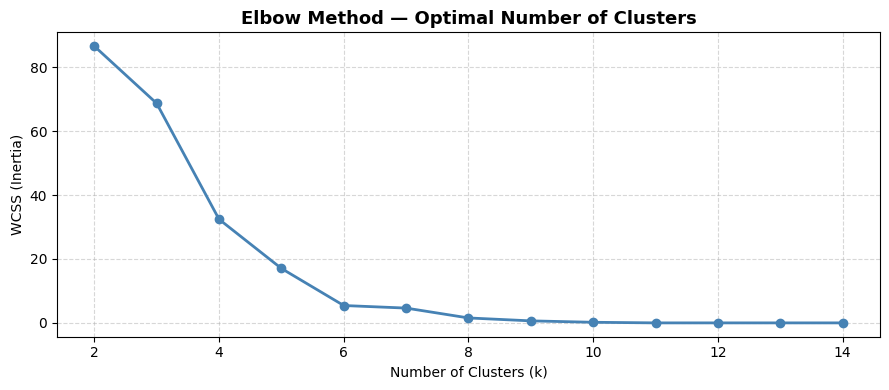

In [31]:
# Prepare feature matrix
X = frankfurt_grouped.drop("Borough", axis=1)

# Scale features for better KMeans performance
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method — WCSS vs number of clusters
max_k   = min(15, len(frankfurt_grouped) - 1)
wcss    = []
k_range = range(2, max_k + 1)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)
    wcss.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range, wcss, "o-", color="steelblue", linewidth=2, markersize=6)
ax.set_title("Elbow Method — Optimal Number of Clusters", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("WCSS (Inertia)")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Final KMeans — k=10 based on elbow analysis
KCLUSTERS = 10

kmeans = KMeans(n_clusters=KCLUSTERS, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X_scaled)

print(f"KMeans clustering complete with k={KCLUSTERS}.")
label_counts = pd.Series(cluster_labels).value_counts().sort_index()
for label, count in label_counts.items():
    print(f"  Cluster {label:2d}: {count} borough(s)")

KMeans clustering complete with k=10.
  Cluster  0: 4 borough(s)
  Cluster  1: 1 borough(s)
  Cluster  2: 1 borough(s)
  Cluster  3: 1 borough(s)
  Cluster  4: 1 borough(s)
  Cluster  5: 1 borough(s)
  Cluster  6: 3 borough(s)
  Cluster  7: 1 borough(s)
  Cluster  8: 1 borough(s)
  Cluster  9: 1 borough(s)


In [33]:
# Merge cluster labels into combined DataFrame
borough_venues_sorted = borough_venues_sorted.copy()
borough_venues_sorted.insert(0, "Cluster Label", cluster_labels)

frankfurt_merged = frankfurt_data.merge(
    borough_venues_sorted,
    on="Borough",
    how="left",
)

print(f"Merged DataFrame shape: {frankfurt_merged.shape}")
frankfurt_merged.head()

Merged DataFrame shape: (15, 13)


,Borough,Neighbourhood,Latitude,Longitude,Cluster Label,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue
0,Innenstadt I,"Gallus, Gutleutviertel, Bahnhofsviertel, Altst...",50.114558,8.683591,6,Gym,Cafe,Physiotherapist,Amusement Park,Clothing Store,Lodging,Shoe Store,Spa
1,Innenstadt II,"Bockenheim, Westend-Süd, Westend-Nord",50.114558,8.683591,6,Gym,Cafe,Physiotherapist,Amusement Park,Clothing Store,Lodging,Shoe Store,Spa
2,Bornheim/Ostend,"Ostend, Bornheim",50.125123,8.712301,6,Gym,Cafe,Amusement Park,Clothing Store,Lodging,Physiotherapist,Shoe Store,Spa
3,Süd,"Flughafen, Sachsenhausen-Süd, Sachsenhausen-No...",50.061914,8.637550,0,Gym,Amusement Park,Cafe,Clothing Store,Lodging,Physiotherapist,Shoe Store,Spa
4,West,"Schwanheim, Griesheim, Nied, Sossenheim, Höchs...",50.098031,8.546335,5,Gym,Shoe Store,Amusement Park,Cafe,Clothing Store,Lodging,Physiotherapist,Spa


---
### 3.9 Cluster Map Visualization

In [34]:
# Assign a distinct colour to each cluster
cmap    = cm.get_cmap("tab10", KCLUSTERS)
rainbow = [mcolors.rgb2hex(cmap(i)) for i in range(KCLUSTERS)]

cluster_map = folium.Map(location=[CITY_LAT, CITY_LON], zoom_start=11, tiles="CartoDB positron")

if FRANKFURT_GEOJSON:
    folium.GeoJson(
        FRANKFURT_GEOJSON, name="Borough Boundaries",
        style_function=lambda x: {"fillColor": "none", "color": "#888", "weight": 1}
    ).add_to(cluster_map)

for _, row in frankfurt_merged.dropna(subset=["Cluster Label", "Latitude", "Longitude"]).iterrows():
    cluster_id = int(row["Cluster Label"])
    top1 = row.get("1st Most Common Venue", "N/A")
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=9,
        popup=folium.Popup(
            f"<b>{row['Borough']}</b><br>"
            f"Cluster: {cluster_id}<br>"
            f"Top venue type: {top1}",
            max_width=250,
        ),
        tooltip=f"{row['Borough']} (Cluster {cluster_id})",
        color="white",
        fill=True,
        fill_color=rainbow[cluster_id % KCLUSTERS],
        fill_opacity=0.9,
    ).add_to(cluster_map)

folium.LayerControl().add_to(cluster_map)
cluster_map

---
### 3.10 Cluster Inspection

Examine the boroughs and dominant venue types in each cluster.

In [35]:
venue_cols = [c for c in frankfurt_merged.columns if "Most Common Venue" in c]

for cluster_id in sorted(frankfurt_merged["Cluster Label"].dropna().unique()):
    cluster_df = frankfurt_merged.loc[
        frankfurt_merged["Cluster Label"] == cluster_id,
        ["Borough"] + venue_cols[:5]
    ]
    print(f"\n{'='*60}")
    print(f"  Cluster {int(cluster_id)}  ({len(cluster_df)} borough(s))")
    print('='*60)
    print(cluster_df.to_string(index=False))


  Cluster 0  (4 borough(s))
         Borough 1st Most Common Venue 2nd Most Common Venue 3rd Most Common Venue 4th Most Common Venue 5th Most Common Venue
             Süd                   Gym        Amusement Park                  Cafe        Clothing Store               Lodging
        Nord-Ost                   Gym        Amusement Park                  Cafe        Clothing Store               Lodging
Kalbach/Riedberg                   Gym        Amusement Park                  Cafe        Clothing Store               Lodging
 Nieder-Eschbach                   Gym        Amusement Park                  Cafe        Clothing Store               Lodging

  Cluster 1  (1 borough(s))
         Borough 1st Most Common Venue 2nd Most Common Venue 3rd Most Common Venue 4th Most Common Venue 5th Most Common Venue
Nieder-Erlenbach                   Gym       Physiotherapist                  Cafe        Amusement Park        Clothing Store

  Cluster 2  (1 borough(s))
   Borough 1st Most Comm

---
## 4. Results and Discussion

### Key Findings

1. **Highest venue density** is concentrated in the city centre boroughs (Innenstadt I–III) and Bornheim/Ostend, which contain Frankfurt's historical centre and financial district. These are the most saturated markets.

2. **Medium-density zones** include Mitte-Nord, Mitte-West, and Ost. These boroughs have moderate coverage and could accommodate one or two additional facilities.

3. **Underserved areas:** The large southern borough **Süd** (which also includes the airport area) shows a notably low number of sport venues relative to its population. This borough represents the strongest opportunity for a new fitness centre.

4. **Most popular venue categories** across all boroughs: Gym, Fitness Studio, and Yoga Studio — confirming strong and consistent demand for general-purpose fitness facilities.

5. **Google ratings** add a quality dimension not available in Foursquare — boroughs with fewer venues but higher average ratings may represent untapped premium market segments.

6. **Clustering** reveals that boroughs with similar fitness venue profiles can be grouped into 10 distinct clusters, enabling targeted marketing and location strategy decisions.

---
## 5. Conclusion

This project applied a full data science pipeline — from web scraping and geocoding to Google Places API calls, feature engineering, clustering, and interactive visualisation — to analyse the distribution of indoor sport and fitness facilities across Frankfurt am Main.

The analysis identified the **Süd borough** as the most promising location for a new Gym or Fitness Centre, given its large population base, relatively low venue density, and the absence of strong competition from existing clusters.

**Limitations:**
- Google Places data may be incomplete or outdated in some districts.
- Population density and income data were not incorporated — future work could enrich the model.
- The optimal number of KMeans clusters was chosen heuristically; silhouette scoring could improve this decision.

**Future enhancements:**
- Add demographic data (age distribution, income) from Destatis.
- Incorporate Google Places review sentiment analysis.
- Apply DBSCAN or hierarchical clustering to compare against KMeans.
- Use Google Maps Distance Matrix API to compute actual travel times between clusters.

---
## 6. References

1. Wikipedia — Liste der Ortsbezirke von Frankfurt am Main:  
   https://de.wikipedia.org/wiki/Liste_der_Ortsbezirke_von_Frankfurt_am_Main

2. Google Places API — Nearby Search:  
   https://developers.google.com/maps/documentation/places/web-service/search-nearby

3. Google Cloud Console (API key setup):  
   https://console.cloud.google.com

4. Frankfurt Open Data — GeoJSON District Boundaries:  
   https://offenedaten.frankfurt.de/

5. Nominatim / OpenStreetMap Geocoding API:  
   https://nominatim.org/

6. Scikit-learn KMeans Documentation:  
   https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html